In [1]:
import numpy as np
import matplotlib.pyplot as plt

from vega import BuildConfig, FitResults, VegaInterface, pktoxi

plt.rcParams['font.size'] = 14
%matplotlib inline

In [2]:
vega = VegaInterface('configs/main-example_v0.ini')

Initializing Vega version 1.7.7.dev65+g0f05df454
INFO: reading input Pk /global/cfs/cdirs/desicollab/users/acuceu/vega_dev/lib/vega/vega/models/Planck18/DESI-2024_z_2.33.fits
Reading data file /global/cfs/cdirs/desicollab/science/lya/y3-fs/validation-tests/v1-4-0-0/baseline/correlations/results/lyalya_lyalya/cf_exp.fits.gz

Reading distortion matrix file /global/cfs/cdirs/desicollab/science/lya/y3-fs/validation-tests/v1-4-0-0/baseline/correlations/results/lyalya_lyalya/dmat.fits.gz

Reading data file /global/cfs/cdirs/desicollab/science/lya/y3-fs/validation-tests/v1-4-0-0/baseline/correlations/results/qso_lyalya/xcf_exp.fits.gz

Reading distortion matrix file /global/cfs/cdirs/desicollab/science/lya/y3-fs/validation-tests/v1-4-0-0/baseline/correlations/results/qso_lyalya/xdmat.fits.gz



## Initialize 2D P(k) model and k/muk grids

In [3]:
params = vega.params
params['peak'] = False

# Replace this with your own computation of 2D Lya P(k) models (e.g., using EFT)
test_pk_models = {
    name: vega.models[name].Pk_core.compute(vega.fiducial['pk_full'], params) for name in vega.corr_items
}

k_grid = vega.fiducial['k']
muk_grid = vega.models['lyaxlya'].Pk_core.muk_grid

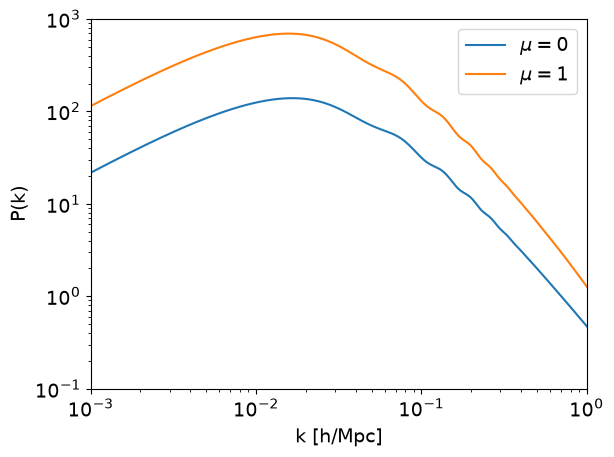

In [4]:
plt.loglog(k_grid, test_pk_models['lyaxlya'][0], label=r'$\mu=0$')
plt.loglog(k_grid, test_pk_models['lyaxlya'][-1], label=r'$\mu=1$')
plt.ylim(1e-1, 1e3)
plt.xlim(1e-3, 1e0)
plt.xlabel(r'k [h/Mpc]')
plt.ylabel(r'P(k)')
plt.legend()

## Compute custom Xi model for input P(k)

In [5]:
xi_model = {
    name: vega.models[name].compute_from_input_pk_model(params, k_grid, muk_grid, test_pk_models[name]) for name in vega.corr_items
}

Reading desi_instrumental_systematics table /global/cfs/cdirs/desicollab/users/acuceu/vega_dev/lib/vega/vega/models/instrumental_systematics/desi-instrument-syst-for-forest-auto-correlation.csv


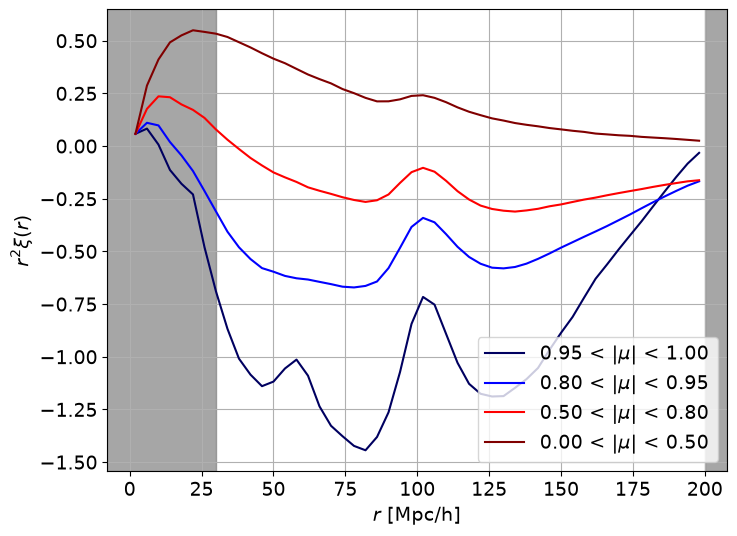

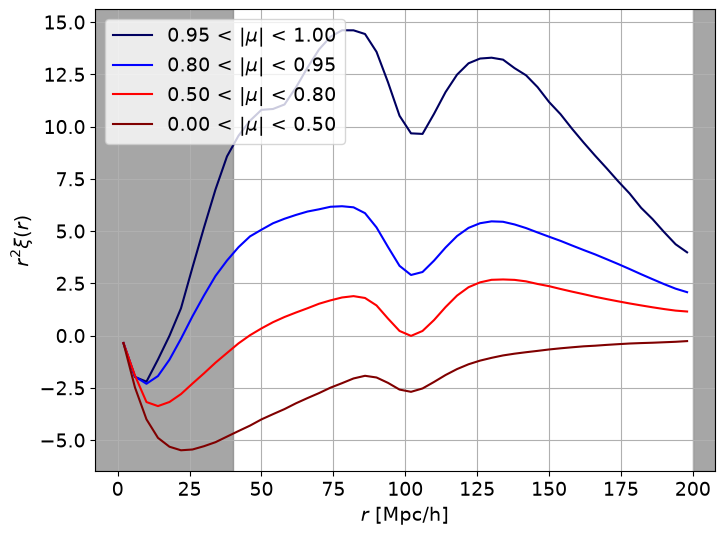

In [6]:
vega.plots.plot_4wedge_panel(model=xi_model['lyaxlya'], model_only=True)
vega.plots.plot_4wedge_panel(model=xi_model['lyaxqso'], model_only=True, corr_name='lyaxqso', cross_flag=True)

## Now with custom coordinate grids

In [7]:
test_pk_models = {
    name: vega.models[name].Pk_core.compute(vega.fiducial['pk_full'], params) for name in vega.corr_items
}

# In this case, I am just cutting the k_grid to simulate a different coordinate grid
for name in test_pk_models:
    test_pk_models[name] = test_pk_models[name][:, :800]

k_grid = vega.fiducial['k'][:800]
muk_grid = vega.models['lyaxlya'].Pk_core.muk_grid

In [8]:
xi_model = {
    name: vega.models[name].compute_from_input_pk_model(params, k_grid, muk_grid, test_pk_models[name]) for name in vega.corr_items
}

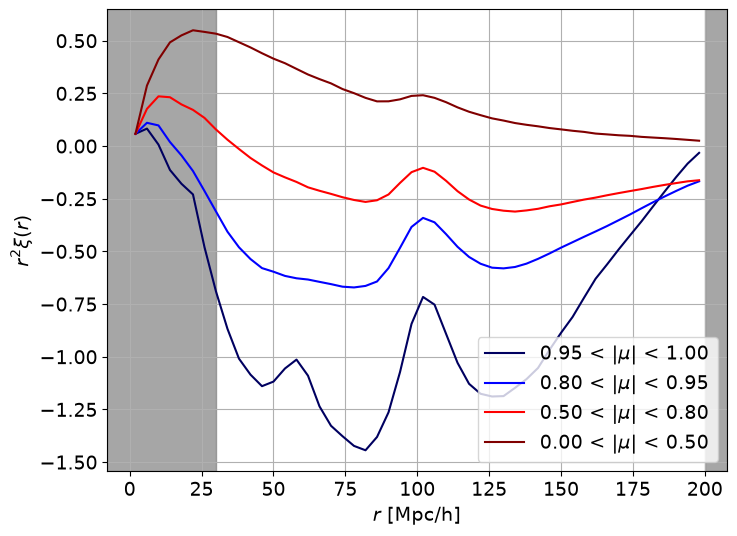

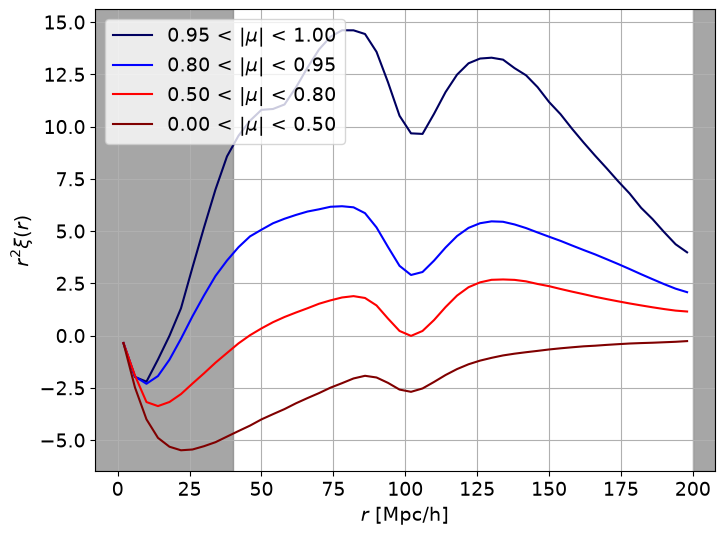

In [9]:
vega.plots.plot_4wedge_panel(model=xi_model['lyaxlya'], model_only=True)
vega.plots.plot_4wedge_panel(model=xi_model['lyaxqso'], model_only=True, corr_name='lyaxqso', cross_flag=True)

## Turning off metals for some components:

In [12]:
xi_model_no_metals = vega.models['lyaxlya'].compute_from_input_pk_model(params, k_grid, muk_grid, test_pk_models['lyaxlya'], no_metals=True)

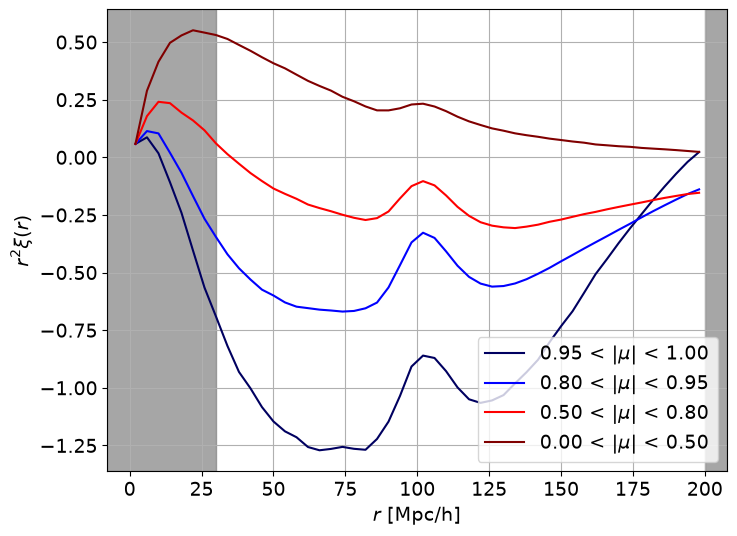

In [13]:
vega.plots.plot_4wedge_panel(model=xi_model_no_metals, model_only=True)